# Two Realignments: 1964 and 2016

*An analysis notebook for the Geo-Fluid Dynamics Engine. This is exploratory
narrative — it calls the project's tested library (`geofluid`) for the real
computation and tells the story around it.*

## The bottom line (plain language)

American politics doesn't just drift — every so often it **realigns**: the
coalitions re-sort onto a new dividing line, and the old way of predicting
elections stops working overnight.

Using county results from **1868 to 2024**, we measured how far each county
landed from the trajectory its own recent history predicted — the
**"surprise."** Two elections stand out as large, geographically organized
surprises — true realignments rather than noise:

* **1964** — the **South** broke away. While the rest of the country surged
  Democratic in the Johnson landslide, the Southern counties that had voted
  Democratic since the Civil War lurched the other way. The dividing line was
  **region** (and the race politics underneath it). This began the long flip
  that handed the once-"Solid South" to the party of Lincoln.
* **2016** — a **new** dividing line appeared: **education**. The surprise
  still had a regional shape (it was concentrated *outside* the South, in the
  industrial Midwest), but layered on top of that older geography was
  something the 1964 map never showed — it tracked a county's **college
  share**: more-educated counties surprised toward Democrats, less-educated
  toward Trump.

Same kind of event — a large, coherent break the old trend couldn't see —
twice, sixty years apart. But the *shape* differs: 1964 was almost purely
**regional**, while 2016 layered a **new education cleavage** on top of a map
that was still regional. A realignment doesn't only swap the dividing line; it
can add one.

## For the technically inclined

For a target election we fit each county's **linear trend** through the eight
prior presidential elections, extrapolate one election ahead, and take the
residual (`geofluid.realignment.trend_surprise`). We then ask three things of
that residual field: how big is it, is it **spatially coherent**
(`geofluid.spatial.moran.morans_i` — a realignment is organized, noise is
not), and which **axis** it correlates with (region vs. education). Caveats
are at the bottom; the linear baseline is deliberately simple.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyreadr

# Resolve the repo root so paths work whether this runs from notebooks/ or the
# repo root (nbconvert executes from the notebook's own directory).
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())

from geofluid.ingest.county_geometry import county_shapefile_to_geojson
from geofluid.ingest.county_returns import load_county_returns
from geofluid.ingest.historical_returns import load_historical_returns
from geofluid.panel.spine import build_returns_spine
from geofluid.realignment import trend_surprise
from geofluid.spatial.moran import morans_i
from geofluid.spatial.weights import county_adjacency

warnings.filterwarnings("ignore")

### Data prerequisites (to re-run)
All paths are relative to the repo root; these inputs are gitignored:
* `data/raw/_hist_pres.RData` — Algara–Sharif 1868–2020 returns (free:
  Harvard Dataverse doi:10.7910/DVN/DGUMFI, file id 5028532, gunzip the
  `.tab`). Read here via `pyreadr`.
* `data/raw/countypres_2000-2024.csv` — MIT 2000–2024 returns (manual
  guestbook download).
* `data/raw/cb_2021/cb_2021_us_county_500k.shp` — Census county geometry.
* `web/public/data/metrics_2024.json` — committed; supplies county college
  share, so no Census API key is needed to re-run this notebook.

In [2]:
# Build the validated 1868–2024 spine from both sources (tested loaders).
hist = load_historical_returns(
    pyreadr.read_r(str(ROOT / "data/raw/_hist_pres.RData"))["pres_elections_release"]
)
modern = load_county_returns(pd.read_csv(ROOT / "data/raw/countypres_2000-2024.csv"))
spine = build_returns_spine(hist, modern)
adjacency = county_adjacency(
    county_shapefile_to_geojson(str(ROOT / "data/raw/cb_2021/cb_2021_us_county_500k.shp"))
)
print(
    f"spine: {len(spine):,} county-years, {spine['year'].nunique()} elections "
    f"{spine['year'].min()}–{spine['year'].max()}"
)

spine: 116,983 county-years, 40 elections 1868–2024


## 1. How surprising was each election?

The median county's distance from its own trend. Small in calm years; large
when the map breaks from its trajectory.

In [3]:
SOUTH = {"01", "05", "12", "13", "22", "28", "37", "45", "47", "48", "51"}  # ex-Confederate states
targets = [1964, 1972, 2016, 2024]
rows = []
surprises = {}
for year in targets:
    s = trend_surprise(spine, target_year=year, value_column="dem_share_2p")
    surprises[year] = s
    south = s[[f for f in s.index if f[:2] in SOUTH]]
    rest = s[[f for f in s.index if f[:2] not in SOUTH]]
    rows.append(
        {
            "election": year,
            "median |surprise| (pts)": round(s.abs().median() * 100, 1),
            "spatial coherence (Moran I)": round(morans_i(s, adjacency), 2),
            "South mean (pts)": round(south.mean() * 100, 1),
            "non-South mean (pts)": round(rest.mean() * 100, 1),
        }
    )
summary = pd.DataFrame(rows).set_index("election")
summary

,median |surprise| (pts),spatial coherence (Moran I),South mean (pts),non-South mean (pts)
election,,,,
1964,22.9,0.89,-0.3,24.2
1972,11.7,0.59,-14.7,-11.0
2016,7.3,0.71,-4.7,-9.4
2024,3.3,0.66,2.3,1.0


1964 and 2016 are the standouts: large surprises with **high spatial
coherence** (Moran's I — the misses cluster, they aren't random). Note the
*direction*: in **1964** the South diverges hard from a nation surging
Democratic; in **2016** the Republican surprise is in the **non-South**.

## 2. Which axis did each realignment run on?

We correlate each county's surprise with two candidate dividing lines: being
in the **South** (region) and its **college share** (education). The strength
of each correlation says how much that axis organized the surprise — and, as
we'll see, a realignment can load on more than one axis at once.

In [4]:
# convert_axes=False keeps the FIPS keys as zero-padded strings ("01001"); the
# default would coerce them to ints (1001), losing the leading zero and failing
# to align with the county surprise series, which is string-keyed.
edu = pd.read_json(ROOT / "web/public/data/metrics_2024.json", orient="index", convert_axes=False)[
    "pct_bachelors_plus"
].rename("college")
axis_rows = []
for year in (1964, 2016):
    s = surprises[year]
    is_south = pd.Series({f: float(f[:2] in SOUTH) for f in s.index})
    joined = pd.concat([s.rename("surprise"), edu], axis=1).dropna()
    axis_rows.append(
        {
            "election": year,
            "corr with region (is South)": round(s.corr(is_south), 2),
            "corr with education (college)": round(joined["surprise"].corr(joined["college"]), 2),
        }
    )
axes = pd.DataFrame(axis_rows).set_index("election")
axes

,corr with region (is South),corr with education (college)
election,,
1964,-0.58,0.24
2016,0.39,0.36


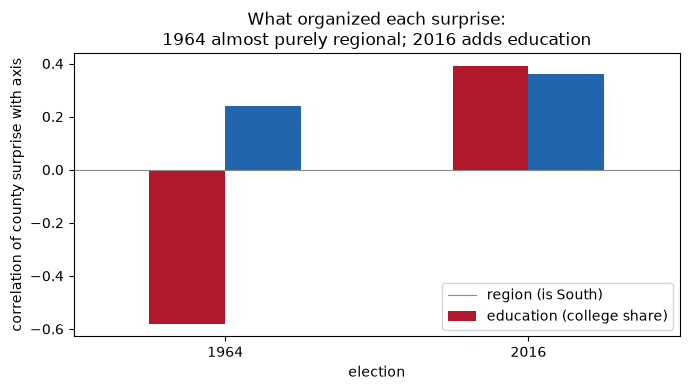

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
axes.plot.bar(ax=ax, color=["#b2182b", "#2166ac"], rot=0)
ax.axhline(0, color="#888", linewidth=0.8)
ax.set_ylabel("correlation of county surprise with axis")
ax.set_title("What organized each surprise:\n1964 almost purely regional; 2016 adds education")
ax.legend(["region (is South)", "education (college share)"])
plt.tight_layout()
plt.show()

The numbers tell a subtler story than a clean swap. **1964's** surprise is
overwhelmingly *regional* (−0.58 with "is South": the South diverged from
everyone else) with only a faint education tilt. **2016's** surprise loads on
**both** axes at once and at similar strength — *educational* (≈0.36 with
college share) **and** still *regional* (≈0.39: the non-South Midwest carried
the larger Republican surprise). So 2016 didn't simply replace region with
education; it added a new education cleavage on top of an older regional one.

## 3. The 2016 diploma divide, county by county

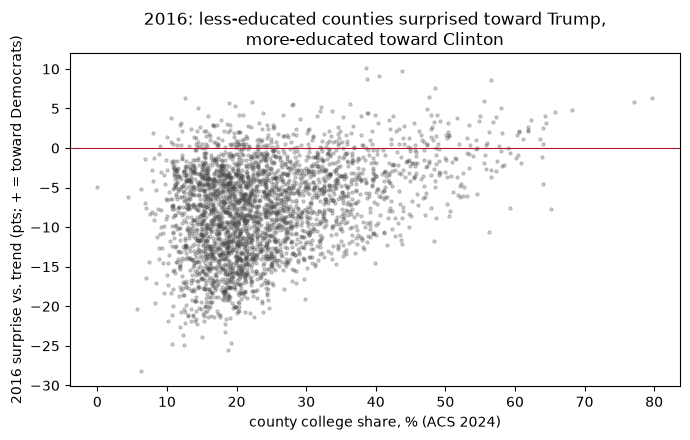

In [6]:
s16 = surprises[2016]
j = pd.concat([s16.rename("surprise"), edu], axis=1).dropna()
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(j["college"] * 100, j["surprise"] * 100, s=5, alpha=0.25, color="#444")
ax.axhline(0, color="#b2182b", linewidth=0.8)
ax.set_xlabel("county college share, % (ACS 2024)")
ax.set_ylabel("2016 surprise vs. trend (pts; + = toward Democrats)")
ax.set_title("2016: less-educated counties surprised toward Trump,\nmore-educated toward Clinton")
plt.tight_layout()
plt.show()

## Conclusion

1964 and 2016 were the same *kind* of event — a large, spatially coherent
break onto a cleavage the prior trend couldn't anticipate — separated by
sixty years. Their shapes differ: 1964 was almost purely regional, while 2016
layered a new education divide on top of a still-regional map. This is
why long-range election forecasting fails across a realignment, and it's the
motivating idea behind the engine's planned Chaos Sensor (Module 4): watch
the surprise field, and when it grows *and* organizes onto a new axis, a
realignment is underway.

### Honest caveats
* The trend baseline is **linear** — deliberately simple. A county's true
  trajectory is not a straight line, so residuals overstate "surprise" in
  landslide years (1964's raw magnitude is inflated by the Johnson landslide;
  the cleaner realignment signal there is the *regional contrast*, not the
  headline number).
* 1948's Dixiecrat run sits inside 1964's training window, adding noise to
  Deep-South trends; the broad 11-state "South" dilutes the sharper Deep-South
  flip.
* Education is measured at one point (ACS 2024) and used as a stable county
  trait; this is descriptive, not a causal or time-resolved claim.
* This is exploratory analysis, not a validated forecasting model.